# **Exploratory Data Analysis (EDA) for predictive employee attrition modelling**


---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\ryan_\\VS-code-projects\\predictive-employee-attrition-modelling\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\ryan_\\VS-code-projects\\predictive-employee-attrition-modelling'

# Section 1 - setting the scence 

Before analyzing the HR dataset, we must apply these core statistical principles to ensure our insights are mathematically sound:
+ Mean & Median: The Mean (average) provides a central balance point but is sensitive to outliers. The Median (middle value) is a "robust" measure, offering a truer sense of "typical" values in skewed data, like salary. 

+ Standard Deviation ($\sigma$): Measures the "spread" or volatility of the data. High deviation indicates high variability in employee attributes, while low deviation suggests consistency.

+ Probability: The likelihood of an event occurring (e.g., Attrition = Yes). This is the engine of Machine Learning; models calculate the probability of a class before making a final prediction.

+ Hypothesis Testing: A method to prove if a correlation (e.g., "Overtime leads to Attrition") is statistically significant or just a random coincidence, typically validated by a p-value (target $< 0.05$).

The Foundation: These concepts allow us to move from description (what happened?) to inference (why did it happen?) and finally to prediction (what will happen next?).

---

## Section 2 - Quick Dataset Overview 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

df = pd.read_csv("data/processed/attrition_clean_v1.csv")

In [5]:
df.shape
df.info()
df.describe()
df['Attrition'].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

This data has 1470 records relating to employees. it has 31 columns that include financial, demographic and job-related attributes. During the ETL no missing values were detected. As previosuly mentioned in *01_ETL.ipynb* the target variable *Attrition*, which shows if an employee has left or note represnts 16 % of employees in this dataset. This suggests we have moderate level of class imbalance, but it should be sufficient to represent modelling later on. 

## Section 3 - Hypothesis Exploration

### Hypothesis 1: Compensation and Attrition

### Business question:

Are employees with lower salaries more likely to leave the organisation?

### Feature(s):
MonthlyIncome (type: numeric)

### Null hypothesis (H0):
There is no difference in MonthlyIncome between employees who leave the organisation and those who stay.

### Alternative hypothesis (H1):
Employees with lower MonthlyIncome are more likely to leave the organisation than those with higher income.

### EDA approach: 
Because MonthlyIncome is a numeric variable and Attrition is categorical, a boxplot can be used to compare income distributions between employees who left and those who stayed.

In [13]:
df.groupby("Attrition")["MonthlyIncome"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
Yes,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


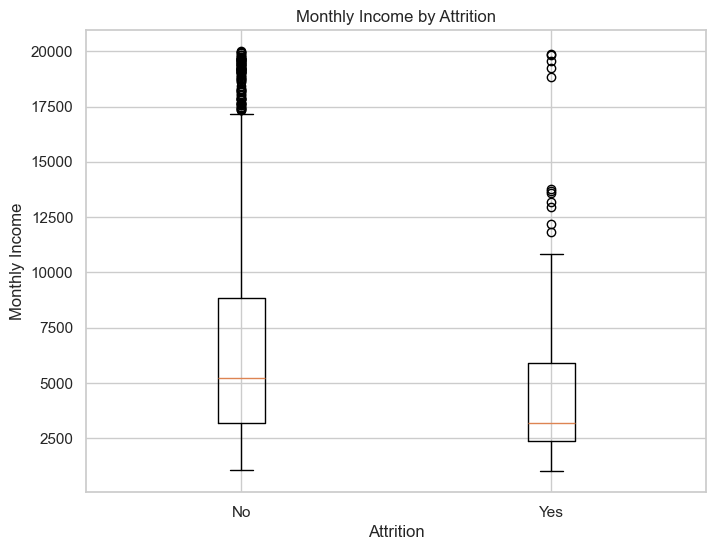

In [15]:
plt.figure(figsize=(8, 6))

attrition_groups = [
    df[df["Attrition"] == "No"]["MonthlyIncome"],
    df[df["Attrition"] == "Yes"]["MonthlyIncome"]
]

plt.boxplot(attrition_groups, labels=["No", "Yes"])
plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

### Mean income split by attrition

In [16]:
income_means = df.groupby("Attrition")["MonthlyIncome"].mean()
print(income_means)

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64


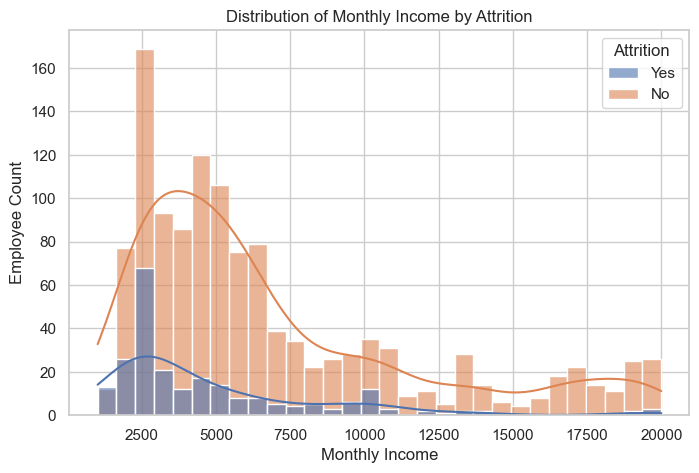

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="MonthlyIncome",
    hue="Attrition",
    bins=30,
    kde=True,
    alpha=0.6
)

plt.title("Distribution of Monthly Income by Attrition")
plt.xlabel("Monthly Income")
plt.ylabel("Employee Count")

plt.show()

The distribution of monthly income shows that employees who left the organisation are more concentrated in the lower income ranges. In contrast, employees with higher salaries appear less likely to leave. This suggests that compensation may play a role in employee retention.

### Hypothesis 1: Burnout / Workload
 
### Business question:

Do employees who work overtime leave at higher rates?

### Feature(s):
'OverTime' (categorical)

### Null hypothesis (H0):
There is no association with working overtime and Attrition.

### Alternative hypothesis (H1):
There is an association with employees who work overtime and Attrition, so employee who work more overtime are more likely to leave the company. 

### EDA approach: 
Because both OverTime and Attrition are categorical variables, a stacked bar chart can be used to compare attrition counts between employees who work overtime and those who do not.

In [9]:
pd.crosstab(df['OverTime'], df['Attrition'])

Attrition,No,Yes
OverTime,,
No,944,110
Yes,289,127


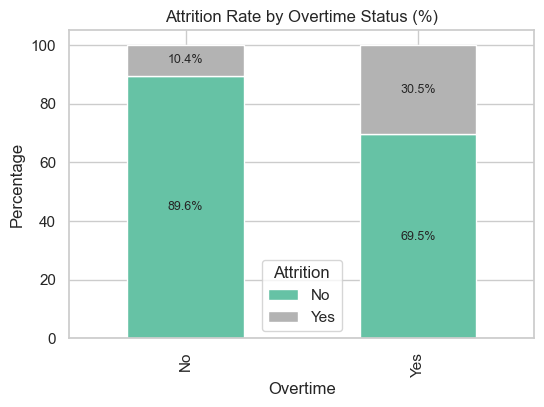

In [10]:
# Create percentage table
overtime_attrition = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100

# Plot
ax = overtime_attrition.plot(
    kind='bar',
    stacked=True,
    figsize=(6,4),
    colormap='Set2'
 )

# Add percentage labels inside each stacked segment - makes it easier to follow!
for container in ax.containers:
    labels = [f"{bar.get_height():.1f}%" if bar.get_height() > 0 else "" for bar in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9)

plt.title('Attrition Rate by Overtime Status (%)')
plt.xlabel('Overtime')
plt.ylabel('Percentage')

plt.legend(title='Attrition')
plt.show()

Employees working overtime show a noticeably higher attrition rate, suggesting workload may influence employee retention. Looking at the percentage rations its clear employees working overtime have a 3 times larger chance of leaving. 10.4% compared to 30.5. This algins with the hypothesis. 

### Hypothesis 3: Job Satisfaction and Attrition

### Business question:
Are employees with lower job satisfaction more likely to leave the organisation?

### Feature(s):
JobSatisfaction (type: categorical / ordinal)

### Null hypothesis (H₀):
There is no association between JobSatisfaction and Attrition.

### Alternative hypothesis (H₁):
Employees with lower job satisfaction are more likely to leave the organisation.

### EDA approach (why this chart/test):
JobSatisfaction has discrete levels, so a countplot allows comparison of attrition across satisfaction scores.

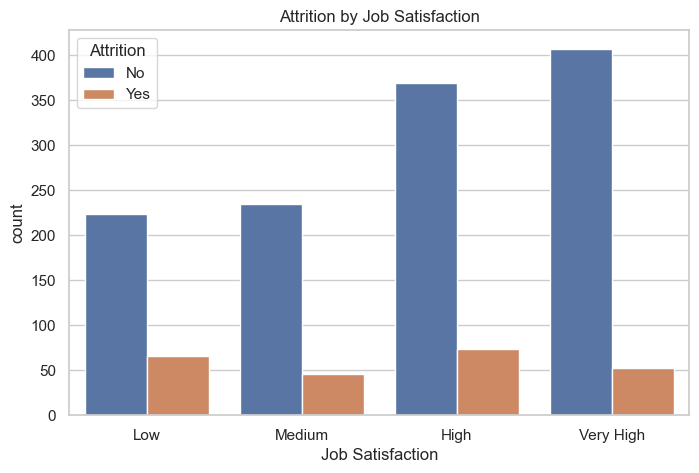

In [ ]:
plt.figure(figsize=(8,5))
#added in labels from the kaggle data source readme which plots 1-4 as low to very high job satisfaction
satisfaction_labels = {
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Very High"
}

ax = sns.countplot(
    data=df,
    x="JobSatisfaction",
    hue="Attrition",
    order=[1, 2, 3, 4]
 )

ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels([satisfaction_labels[i] for i in [1, 2, 3, 4]])
plt.xlabel("Job Satisfaction")
plt.title("Attrition by Job Satisfaction")
plt.show()

### Hypothesis 4: Career Progression and Attrition

### Business question:
Are employees who have not been promoted recently more likely to leave the organisation?

### Feature(s):
YearsSinceLastPromotion (type: numeric)

### Null hypothesis (H₀):
There is no difference in YearsSinceLastPromotion between employees who leave and those who stay.

### Alternative hypothesis (H₁):
Employees who have gone longer without promotion are more likely to leave the organisation.

### EDA approach (why this chart/test):
Because YearsSinceLastPromotion is a numeric variable and Attrition is categorical, a boxplot can be used to compare promotion timelines between employees who left and those who stayed.

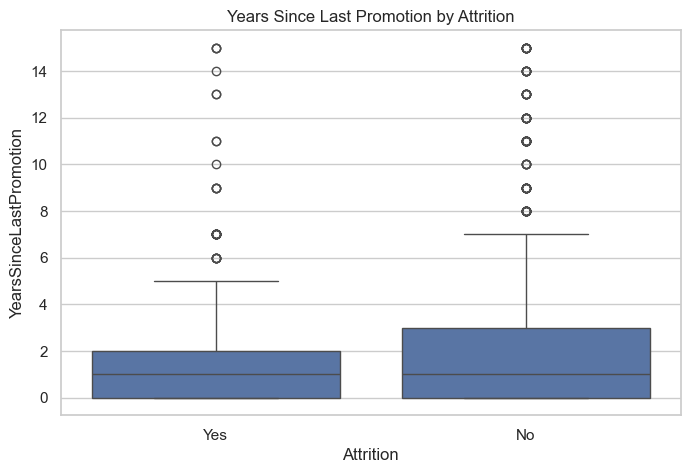

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsSinceLastPromotion"
)

plt.title("Years Since Last Promotion by Attrition")
plt.show()

### Hypothesis 5: Commute Distance and Attrition

### Business question:
Are employees who live farther from the workplace more likely to leave the organisation?

### Feature(s):
DistanceFromHome (type: numeric)

### Null hypothesis (H₀):
There is no difference in DistanceFromHome between employees who leave and those who stay.

### Alternative hypothesis (H₁):
Employees with longer commuting distances are more likely to leave the organisation.

### EDA approach (why this chart/test):
Because DistanceFromHome is numeric and Attrition is categorical, a boxplot can be used to compare commute distance distributions between attrition groups.

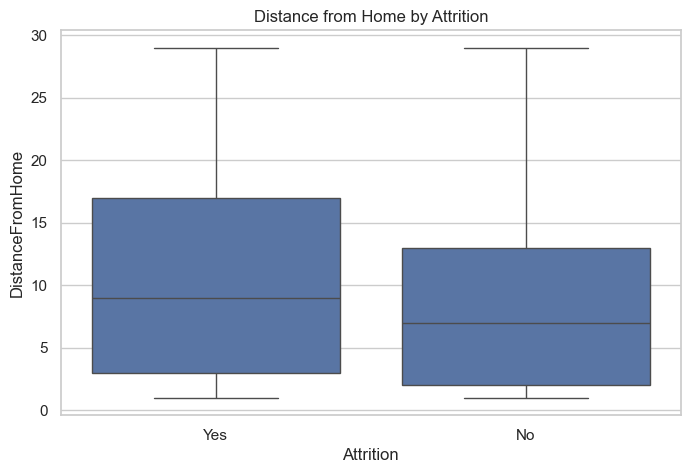

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="DistanceFromHome"
)

plt.title("Distance from Home by Attrition")
plt.show()

<Axes: xlabel='DistanceFromHome', ylabel='Count'>

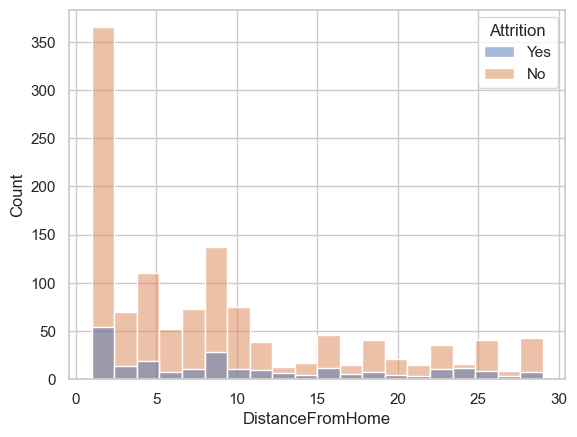

In [25]:
sns.histplot(
    data=df,
    x="DistanceFromHome",
    hue="Attrition",
    bins=20
)

### Hypothesis 6: Tenure and Attrition

### Business question:
Are employees with shorter tenure more likely to leave the organisation?

### Feature(s):
YearsAtCompany (type: numeric)

### Null hypothesis (H₀):
There is no difference in YearsAtCompany between employees who leave and those who stay.

### Alternative hypothesis (H₁):
Employees with shorter tenure are more likely to leave the organisation.

#### EDA approach (why this chart/test):
Because YearsAtCompany is numeric and Attrition is categorical, a histogram or boxplot can be used to compare tenure distributions between attrition groups.

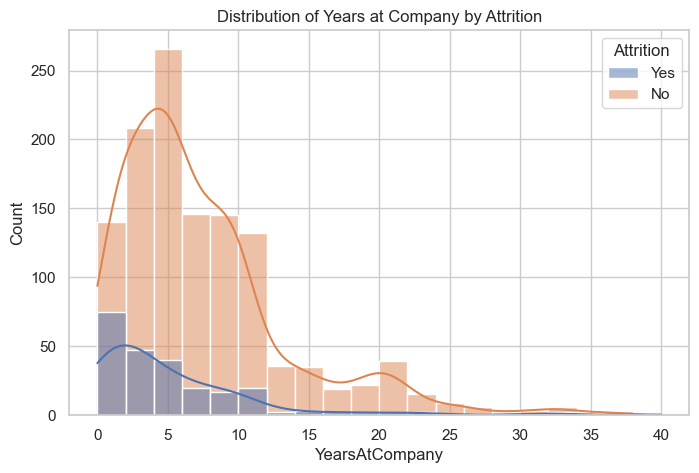

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="YearsAtCompany",
    hue="Attrition",
    bins=20,
    kde=True
)

plt.title("Distribution of Years at Company by Attrition")
plt.show()

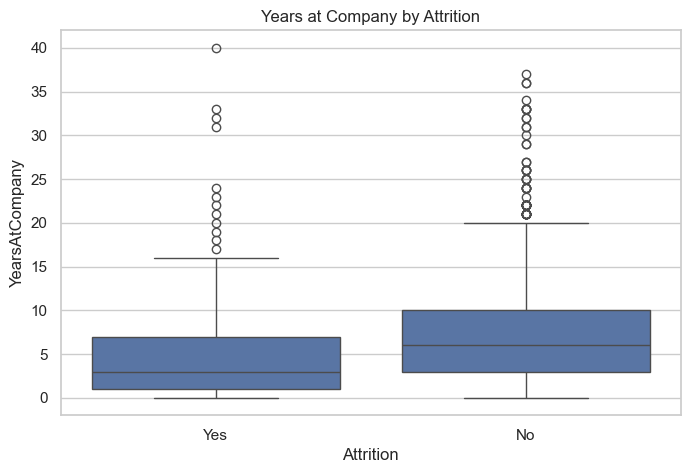

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany"
)

plt.title("Years at Company by Attrition")
plt.show()

Hypothesis Section Template (copy/paste)
Hypothesis [#]: [Short title]

Business question:

(One sentence in plain English.)

Feature(s):

FeatureA (type: categorical/numeric)

FeatureB (optional)

Null hypothesis (H₀):

There is no association / no difference between [Feature] and Attrition.

Alternative hypothesis (H₁):

There is an association / there is a difference between [Feature] and Attrition.
(Directional if you want: “Employees with X have higher attrition.”)

EDA approach (why this chart/test):

(1 sentence: “Because FeatureA is categorical and Attrition is categorical, a stacked bar chart is appropriate.”)

# Section 4 - Correlation Analysis

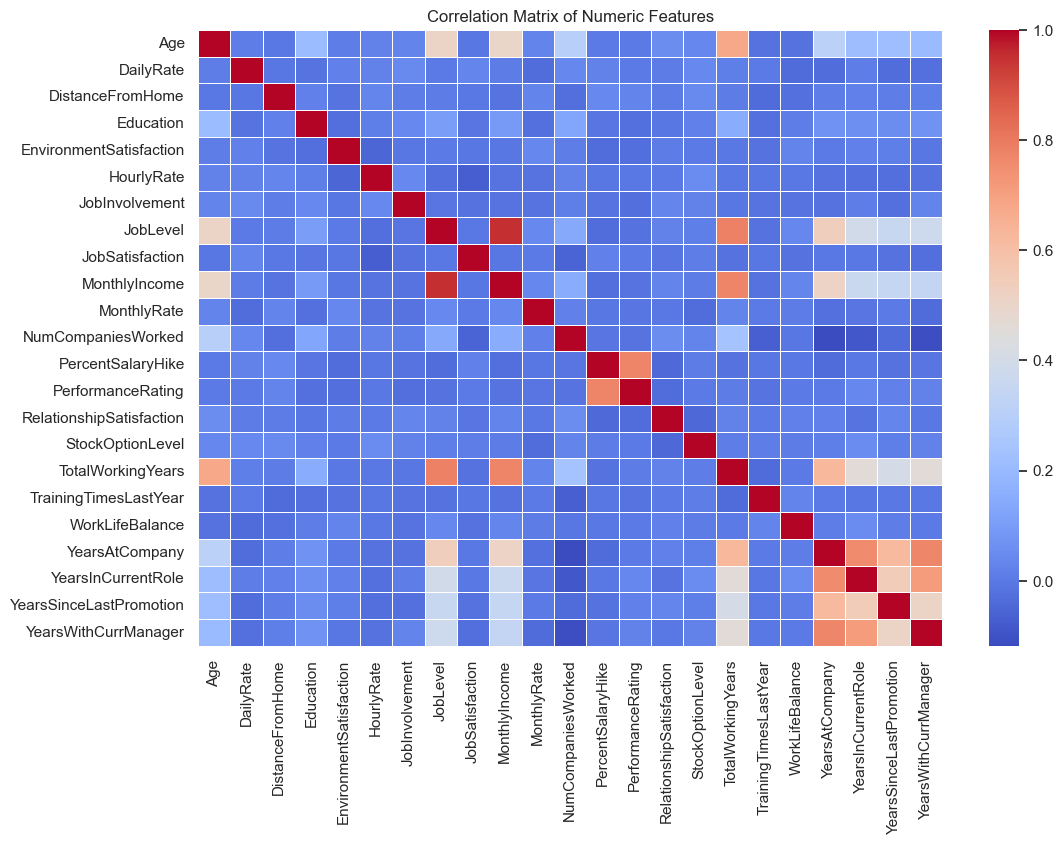

In [ ]:


# Select only numeric variables
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numeric Features")

plt.show()

In [30]:
corr_matrix["MonthlyIncome"].sort_values(ascending=False)

MonthlyIncome               1.000000
JobLevel                    0.950300
TotalWorkingYears           0.772893
YearsAtCompany              0.514285
Age                         0.497855
YearsInCurrentRole          0.363818
YearsSinceLastPromotion     0.344978
YearsWithCurrManager        0.344079
NumCompaniesWorked          0.149515
Education                   0.094961
MonthlyRate                 0.034814
WorkLifeBalance             0.030683
RelationshipSatisfaction    0.025873
DailyRate                   0.007707
StockOptionLevel            0.005408
EnvironmentSatisfaction    -0.006259
JobSatisfaction            -0.007157
JobInvolvement             -0.015271
HourlyRate                 -0.015794
DistanceFromHome           -0.017014
PerformanceRating          -0.017120
TrainingTimesLastYear      -0.021736
PercentSalaryHike          -0.027269
Name: MonthlyIncome, dtype: float64


## Correlation Matrix Interpretation
To get a better handle on how the different numeric features in this dataset interact, I put together a correlation matrix and visualized it with a heatmap. I’m looking at the coefficients on a scale of -1 to +1. In short, anything close to +1 shows a strong positive link, 0 means there’s not much going on, and anything near -1 would suggest the variables move in opposite directions. Looking at the map, there are a few clear patterns popping up around experience and pay.

## Salary and Experience Relationships
The biggest standout for me was the massive link between MonthlyIncome and JobLevel (about 0.95). This totally makes sense—in most companies, as you move up the ladder, your paycheck grows with you.

I also noticed that TotalWorkingYears (0.77) and Age (0.50) have a pretty solid connection to income. It tells a clear story: the more "seasoned" an employee is and the longer they’ve been in the workforce, the more they tend to earn. Tenure at the company (0.51) plays a role too, though it’s not quite as dominant as total industry experience.

## Tenure and Career Progression
I also took a look at the "tenure" block of variables, like:

+ YearsAtCompany

+ YearsInCurrentRole

+ YearsSinceLastPromotion

+ YearsWithCurrManager

These all show moderate correlations with each other, which is what I’d expect. If someone has been at the company for a long time, they naturally tend to have spent more time in their current role or with their current manager. It’s interesting to see how these career milestones all move somewhat in sync.

## Variables With Weak Relationships
On the flip side, some features like DailyRate, MonthlyRate, and DistanceFromHome didn't really show much of a connection to anything else. They seem to just do their own thing. While it’s tempting to ignore them, I know a weak correlation doesn't mean they're useless—it just means they don't have a simple, linear relationship with things like salary or seniority.

## Implications for Predictive Modelling
This analysis gives me a great head start for the modeling phase. I’ve identified the "heavy hitters" like experience and job level that will likely be key predictors.

One thing I need to keep an eye on, though, is multicollinearity. Since JobLevel and MonthlyIncome are so tightly linked (that 0.95 we saw earlier), they might be giving the model the same information twice. When I get to the feature importance stage, I'll have to decide which of these gives the model the most "bang for its buck" without overcomplicating things.